# Linear Regression Project - NBA PPG Prediction

Goal: Building a linear regression model from scratch (NumPy only, no sklearn) to predict a player's points per game (PPG), using a small set of box score features

In [4]:
import pandas as pd
import numpy as np

In [6]:
## read dataset

df = pd.read_csv("./datasets/nba_player_stats_2026.csv")

df

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,1643141,578,Jahmyl Telfort,1610612746,LAC,8,32,0,4,0.000,...,3,1,1,0,1,5,1,-2,1.00,1.00
578,1642935,579,Chucky Hepburn,1610612761,TOR,2,13,0,6,0.000,...,1,2,1,0,1,2,0,-3,2.00,1.00
579,1642468,579,Darius Brown,1610612739,CLE,1,3,0,1,0.000,...,1,0,0,0,0,0,0,0,0.00,0.00
580,1642855,579,Noa Essengue,1610612741,CHI,2,6,0,3,0.000,...,0,0,1,0,0,1,0,-2,0.00,0.00


In [9]:
df.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76


In [22]:
## get view of dataset

df.describe()

print(f"Columns are: {df.columns.tolist()}")

print(f"No. of rows are: {len(df)}")

Columns are: ['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF', 'AST_TOV', 'STL_TOV']
No. of rows are: 582


Features to use to predict PPG:

- FGA (Field goal attempts)
- Minutes played (MP)
- Free throw attempts (FTA)
- Three point attempts (3PA)

In [47]:
# df_clean = df[["PLAYER", "PTS", "FGA", "FG3A", "FTA", "GP"]] # come back to this when done with multiple features

df_clean = df[["PLAYER", "PTS", "FGA", "GP"]] # only using one variable/feature

df_clean

,PLAYER,PTS,FGA,GP
0,Luka Dončić,2143,1457,64
1,Shai Gilgeous-Alexander,2117,1321,68
2,Jaylen Brown,2038,1543,71
3,Kevin Durant,2026,1376,78
4,Tyrese Maxey,1980,1501,70
...,...,...,...,...
577,Jahmyl Telfort,1,4,8
578,Chucky Hepburn,0,6,2
579,Darius Brown,0,1,1
580,Noa Essengue,0,3,2


In [48]:
# features = ["FGA", "MIN", "FTA", "FG3A"]

feature = ['FGA']

target = "PTS"

df_clean

,PLAYER,PTS,FGA,GP
0,Luka Dončić,2143,1457,64
1,Shai Gilgeous-Alexander,2117,1321,68
2,Jaylen Brown,2038,1543,71
3,Kevin Durant,2026,1376,78
4,Tyrese Maxey,1980,1501,70
...,...,...,...,...
577,Jahmyl Telfort,1,4,8
578,Chucky Hepburn,0,6,2
579,Darius Brown,0,1,1
580,Noa Essengue,0,3,2


In [ ]:
# calculating per game stats

for col in ['PTS', 'FGA']:
    df_clean[col] = df_clean[col]/df_clean['GP']

df_clean

,PLAYER,PTS,FGA,GP
0,Luka Dončić,33.484375,22.765625,64
1,Shai Gilgeous-Alexander,31.132353,19.426471,68
2,Jaylen Brown,28.704225,21.732394,71
3,Kevin Durant,25.974359,17.641026,78
4,Tyrese Maxey,28.285714,21.442857,70
...,...,...,...,...
577,Jahmyl Telfort,0.125000,0.500000,8
578,Chucky Hepburn,0.000000,3.000000,2
579,Darius Brown,0.000000,1.000000,1
580,Noa Essengue,0.000000,1.500000,2


Plot everything to get a view of it all

In [58]:
import matplotlib.pyplot as plt
import math

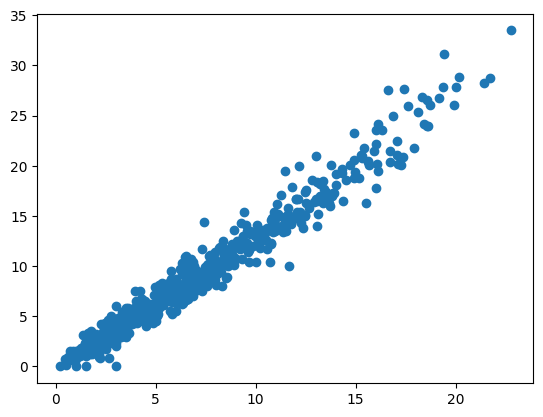

In [52]:
plt.scatter(df_clean["FGA"], df_clean["PTS"])

### Implement Cost Function (Mean Squared Error)

In [54]:
def compute_cost(x, y, w, b):

    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum += cost
    total_cost = (1 / (2 * m)) * cost_sum

    return total_cost


In [55]:
## test compute_cost functionality
x_train = df_clean["FGA"]
y_train = df_clean["PTS"]


compute_cost(x_train, y_train, 5, 0)

np.float64(492.92242966701275)

### Implement gradient descent

In [77]:
# compute gradient

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    
    #let "j" be cost
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (1 / m) * (f_wb - y[i]) * x[i]
        dj_db_i = (1 / m) * (f_wb - y[i])

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    return dj_dw, dj_db

In [78]:
# test compute gradient

compute_gradient(x_train, y_train, 0, 0)

(np.float64(-94.09727985790553), np.float64(-9.154370423418005))

In [81]:
# compute gradient descent
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_func, gradient_func):
    J_history = [] # History of cost values
    p_history = [] # History of parameters [w, b]
    b = b_in
    w = w_in
    
    for i in range(num_iter):
        dj_dw, dj_db = gradient_func(x, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_func(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iter/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                    f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                    f"w: {w: 0.3e}, b:{b: 0.5e}")   
    
    return w, b, J_history, p_history

Gradient descent to get ideal parameters for w and b

In [82]:
# initialise params

w_init = 0
b_init = 0

iterations = 10000
tmp_alpha = 1.0e-2

# execute gradient descent

w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)

Iteration    0: Cost 5.35e+00  dj_dw: -9.410e+01, dj_db: -9.154e+00   w:  9.410e-01, b: 9.15437e-02
Iteration 1000: Cost 7.64e-01  dj_dw: -8.891e-04, dj_db:  8.970e-03   w:  1.347e+00, b:-4.23084e-01
Iteration 2000: Cost 7.63e-01  dj_dw: -4.657e-05, dj_db:  4.698e-04   w:  1.350e+00, b:-4.51862e-01
Iteration 3000: Cost 7.63e-01  dj_dw: -2.439e-06, dj_db:  2.461e-05   w:  1.350e+00, b:-4.53369e-01
Iteration 4000: Cost 7.63e-01  dj_dw: -1.277e-07, dj_db:  1.289e-06   w:  1.350e+00, b:-4.53448e-01
Iteration 5000: Cost 7.63e-01  dj_dw: -6.690e-09, dj_db:  6.749e-08   w:  1.350e+00, b:-4.53452e-01
Iteration 6000: Cost 7.63e-01  dj_dw: -3.504e-10, dj_db:  3.535e-09   w:  1.350e+00, b:-4.53452e-01
Iteration 7000: Cost 7.63e-01  dj_dw: -1.835e-11, dj_db:  1.851e-10   w:  1.350e+00, b:-4.53452e-01
Iteration 8000: Cost 7.63e-01  dj_dw: -9.719e-13, dj_db:  9.696e-12   w:  1.350e+00, b:-4.53452e-01
Iteration 9000: Cost 7.63e-01  dj_dw: -5.815e-14, dj_db:  5.071e-13   w:  1.350e+00, b:-4.53452e-01


In [83]:
print(f"(w, b) found by gradient descent: ({w_final:8.4f}, {b_final:8.4f})")

(w, b) found by gradient descent: (  1.3499,  -0.4535)


Plotting linear regression line

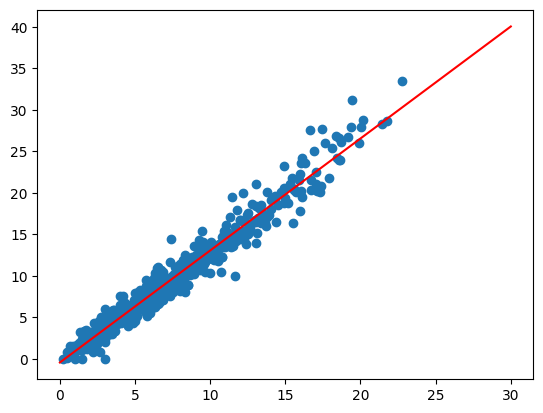

In [94]:
plt.scatter(df_clean["FGA"], df_clean["PTS"])

x_plot = np.arange(0, 35, 5)

y_plot = w_final * x_plot + b_final

plt.plot(x_plot, y_plot, color='r')